## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Read Dataset

In [4]:
df = pd.read_csv("imdb_traffic.csv")

df.head()

,Year,Month,Total_Estimated_Visits,Active_Logged_In_Users,Unique_Users_Rating,Total_Ratings_Submitted,Total_Page_Views,Avg_Session_Duration_Sec
0,2010,January,102483570,15006167,1663546,9331459,589981535,287.6
1,2010,February,106828680,15176123,1695689,9866151,666516233,287.9
2,2010,March,116268827,16444615,1888672,10483181,687969529,241.0
3,2010,April,122675155,17405828,1982592,11447421,691427174,285.2
4,2010,May,111899622,16970404,1890722,10951022,643999625,291.2


## Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      10000 non-null  int64  
 1   Month                     10000 non-null  object 
 2   Total_Estimated_Visits    10000 non-null  int64  
 3   Active_Logged_In_Users    10000 non-null  int64  
 4   Unique_Users_Rating       10000 non-null  int64  
 5   Total_Ratings_Submitted   10000 non-null  int64  
 6   Total_Page_Views          10000 non-null  int64  
 7   Avg_Session_Duration_Sec  10000 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


## Check Missing Values

In [6]:
df.isnull().sum()

,0
Year,0
Month,0
Total_Estimated_Visits,0
Active_Logged_In_Users,0
Unique_Users_Rating,0
Total_Ratings_Submitted,0
Total_Page_Views,0
Avg_Session_Duration_Sec,0


## Statistical Summary

In [7]:
df.describe()

,Year,Total_Estimated_Visits,Active_Logged_In_Users,Unique_Users_Rating,Total_Ratings_Submitted,Total_Page_Views,Avg_Session_Duration_Sec
count,10000.000000,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000
mean,2426.166800,1.999929e+08,3.003657e+07,3.378472e+06,1.942630e+07,1.199769e+09,270.072440
std,240.574699,5.887996e+07,8.952471e+06,1.007718e+06,5.820201e+06,3.591168e+08,17.256617
min,2010.000000,7.604381e+07,1.133372e+07,1.284439e+06,7.404661e+06,4.621589e+08,240.000000
25%,2218.000000,1.500188e+08,2.242917e+07,2.525112e+06,1.452242e+07,8.964948e+08,255.500000
50%,2426.000000,1.994917e+08,2.997140e+07,3.365482e+06,1.937230e+07,1.196391e+09,270.000000
75%,2634.250000,2.500078e+08,3.744486e+07,4.212490e+06,2.421168e+07,1.497623e+09,285.100000
max,2843.000000,3.211633e+08,5.114488e+07,5.773075e+06,3.439335e+07,2.076753e+09,300.000000


## Correlation Matrix

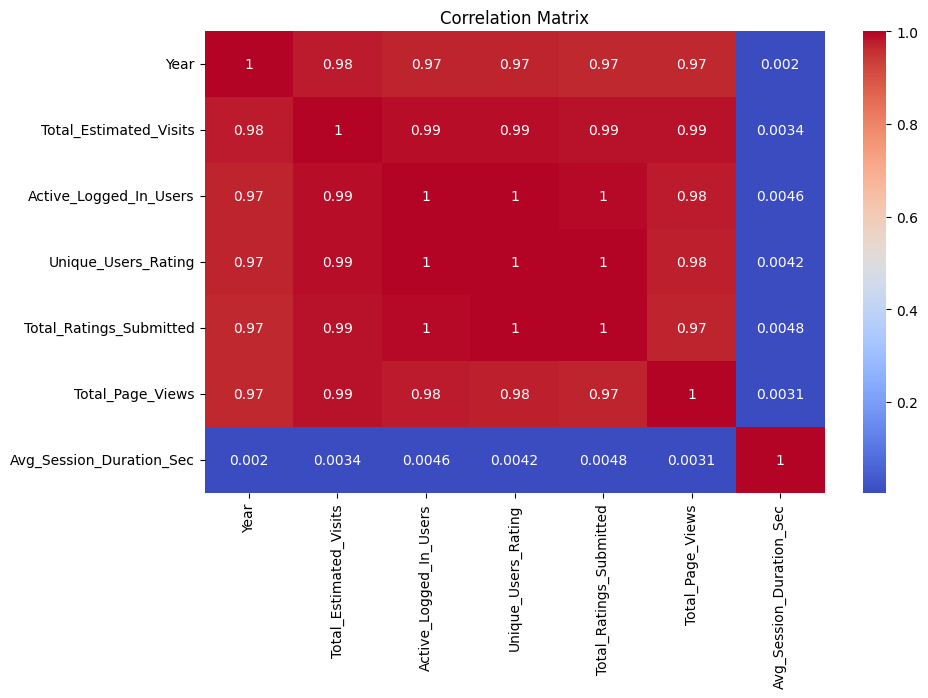

In [8]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

## Distribution of Visits

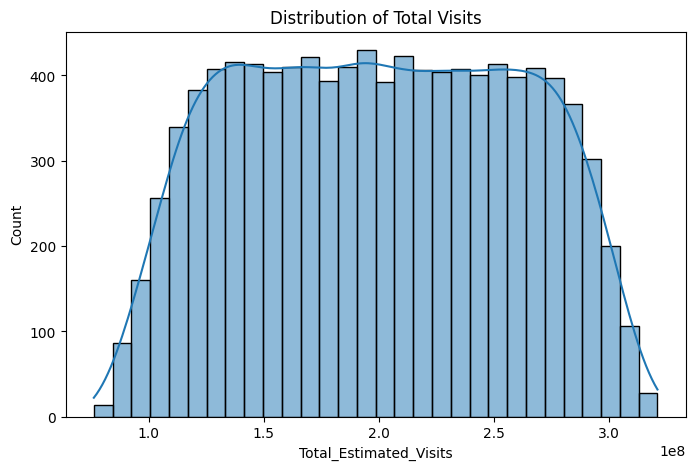

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Total_Estimated_Visits"],
    bins=30,
    kde=True
)

plt.title("Distribution of Total Visits")
plt.show()

## Page Views vs Visits

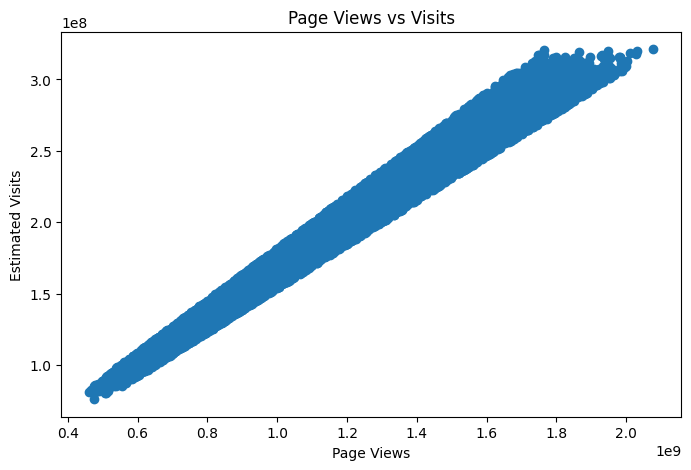

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Total_Page_Views"],
    df["Total_Estimated_Visits"]
)

plt.xlabel("Page Views")
plt.ylabel("Estimated Visits")
plt.title("Page Views vs Visits")

plt.show()

## Select Features and Target

In [11]:
X = df[
    [
        "Active_Logged_In_Users",
        "Unique_Users_Rating",
        "Total_Ratings_Submitted",
        "Total_Page_Views",
        "Avg_Session_Duration_Sec"
    ]
]

y = df["Total_Estimated_Visits"]

## Split Data

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Random Forest Model

In [13]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## Make Predictions

In [14]:
y_pred = rf.predict(X_test)

## Evaluate Model

In [15]:
print("MAE :", mean_absolute_error(y_test, y_pred))

print("RMSE :",
      np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score :",
      r2_score(y_test, y_pred))

MAE : 4916775.150559999
RMSE : 6270133.720839156
R2 Score : 0.9886375425001054


## Actual vs Predicted

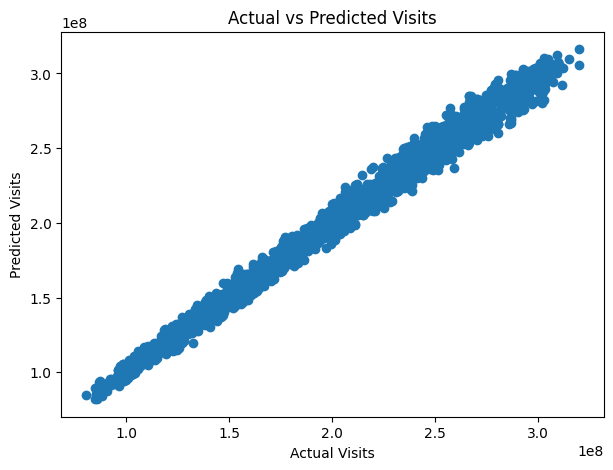

In [16]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Visits")
plt.ylabel("Predicted Visits")
plt.title("Actual vs Predicted Visits")

plt.show()

## Feature Importance

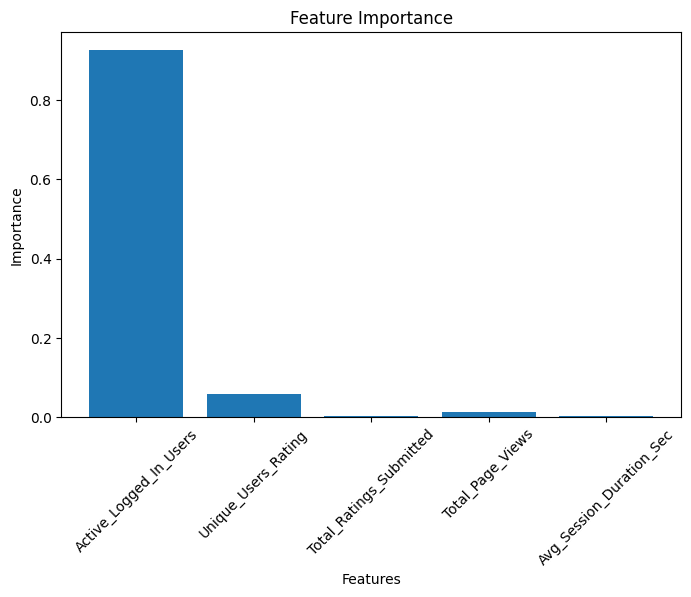

In [17]:
importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.bar(features, importance)

plt.xticks(rotation=45)

plt.xlabel("Features")
plt.ylabel("Importance")

plt.title("Feature Importance")

plt.show()

## Predict New Data

In [18]:
sample = [[
    25000,   # Active users
    12000,   # Unique ratings
    18000,   # Ratings submitted
    500000,  # Page views
    320      # Session duration
]]

prediction = rf.predict(sample)

print("Predicted Visits:", prediction[0])

Predicted Visits: 78732664.84


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
